In [442]:
pip install torch torchvision

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torchvision 
import torchvision.models.detection as models
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection import fasterrcnn_resnet50_fpn

In [3]:
import os 
import numpy as np
import pandas as pd 
import torchvision 
import ast
import re
import cv2 
import seaborn as sns
from torchvision.ops import nms
from sklearn.metrics import auc
from PIL import Image, ImageDraw
from collections import Counter 
import matplotlib.pyplot as plt 
from tqdm import tqdm
from torchvision.ops import box_iou
from sklearn.metrics import precision_score, recall_score, f1_score
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T 
import torchvision.transforms as transforms
from torchvision.models.detection import FasterRCNN

In [7]:
# Hàm tạo mô hình Faster R-CNN
def get_model(num_classes):
    # Sử dụng Faster R-CNN với backbone ResNet50
    # model = models.fasterrcnn_resnet50_fpn(weights=models.FasterRCNN_ResNet50_FPN_Weights.COCO_V1)
    model = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
    
    # Thay đổi đầu ra (head) để phù hợp với số lớp của bạn
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)
    
    # in_features = model.roi_heads.box_predictor.cls_score.in_features
    # model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    
    return model

# Khởi tạo mô hình
num_classes = 7 
model = get_model(num_classes)

In [9]:
checkpoint = torch.load(r"C:\Users\HoangVan\Documents\Zô đây mà xem tài liệu học\Kì 5\Thị giác máy tính nâng cao\Đồ án\Test\model_new\fasterrcnn_resnet50_fpn_epoch_8.pth", map_location='cpu')

C:\Users\HoangVan\AppData\Local\Temp\ipykernel_14408\1788897438.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(r"C:\Users\HoangVan\Documents\Zô 

In [17]:
checkpoint['model_state_dict']

OrderedDict([('backbone.body.conv1.weight',
              tensor([[[[ 1.3335e-02,  1.4664e-02, -1.5351e-02,  ..., -4.0896e-02,
                         -4.3034e-02, -7.0755e-02],
                        [ 4.1205e-03,  5.8477e-03,  1.4948e-02,  ...,  2.2060e-03,
                         -2.0912e-02, -3.8517e-02],
                        [ 2.2331e-02,  2.3595e-02,  1.6120e-02,  ...,  1.0281e-01,
                          6.2641e-02,  5.1977e-02],
                        ...,
                        [-9.0349e-04,  2.7767e-02, -1.0105e-02,  ..., -1.2722e-01,
                         -7.6604e-02,  7.8453e-03],
                        [ 3.5894e-03,  4.8006e-02,  6.2051e-02,  ...,  2.4267e-02,
                         -3.3662e-02, -1.5709e-02],
                        [-8.0029e-02, -3.2238e-02, -1.7808e-02,  ...,  3.5359e-02,
                          2.2439e-02,  1.7077e-03]],
              
                       [[-1.8452e-02,  1.1415e-02,  2.3850e-02,  ...,  5.3736e-02,
                  

In [10]:
model.load_state_dict(checkpoint['model_state_dict'])

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

### Hàm đánh giá 

In [450]:
# Hàm tính IoU
def calculate_iou(box1, box2):
    x1, y1, x2, y2 = box1
    x1g, y1g, x2g, y2g = box2

    xi1, yi1 = max(x1, x1g), max(y1, y1g)
    xi2, yi2 = min(x2, x2g), min(y2, y2g)

    inter_area = max(0, xi2 - xi1) * max(0, yi1 - yi1)
    box1_area = (x2 - x1) * (y2 - y1)
    box2_area = (x2g - x1g) * (y2g - y1g)

    union_area = box1_area + box2_area - inter_area
    iou = inter_area / union_area if union_area != 0 else 0
    return iou

In [451]:
data_val = pd.read_csv(r"data\valid_data.csv")
data_test = pd.read_csv(r"data\test_data.csv")

In [452]:
def convert_bbox(bbox_str): 
    return ast.literal_eval(bbox_str)

In [453]:
data_val['bbox'] = data_val['bbox'].apply(convert_bbox)
data_val['track_id'] = data_val['track_id'].apply(convert_bbox)
data_val['labels'] = data_val['labels'].apply(convert_bbox)

In [454]:
data_test['bbox'] = data_test['bbox'].apply(convert_bbox)
data_test['track_id'] = data_test['track_id'].apply(convert_bbox)
data_test['labels'] = data_test['labels'].apply(convert_bbox)

In [455]:
def convert_bbox(bbox):
    return [ [x, y, x + w, y + h] for x, y, w, h in bbox]

# Áp dụng hàm cho cột 'bbox'
data_val['bbox'] = data_val['bbox'].apply(convert_bbox)

In [456]:
data_test['bbox'] = data_test['bbox'].apply(convert_bbox)

In [457]:
label_mapping = {
    'DNoHelmet': 1,
    'DHelmet': 2,
    'DHelmetPHelmet': 3,
    'DHelmetPNoHelmet': 4,
    'DNoHelmetPHelmet': 5,
    'DNoHelmetPNoHelmet': 6
}

In [458]:
data_val['new_labels'] = data_val['new_labels'].apply(ast.literal_eval)
data_test['new_labels'] = data_test['new_labels'].apply(ast.literal_eval)

In [459]:
data_val['labels_map'] = data_val['new_labels'].apply(lambda labels: [label_mapping[label] for label in labels])
data_test['labels_map'] = data_test['new_labels'].apply(lambda labels: [label_mapping[label] for label in labels])

In [460]:
original_width, original_height = 1920, 1080
new_width, new_height = 512, 512

# Hàm điều chỉnh bounding box
def resize_bbox_list(bbox_list):
    resized_bboxes = []
    for bbox in bbox_list:
        xmin, ymin, xmax, ymax = bbox
        xmin_new = xmin / original_width * new_width
        ymin_new = ymin / original_height * new_height
        xmax_new = xmax / original_width * new_width
        ymax_new = ymax / original_height * new_height
        resized_bboxes.append([xmin_new, ymin_new, xmax_new, ymax_new])
    return resized_bboxes

data_val['bbox_new'] = data_val['bbox'].apply(resize_bbox_list)
data_test['bbox_new'] = data_test['bbox'].apply(resize_bbox_list)

In [461]:
data_test.head()

,image_name,track_id,labels,bbox,image_path,new_labels,labels_map,bbox_new
0,Bago_highway_10_01,"[_qduigg0eu, _iajtqobrr, _y3rk2zkrs]","[DNoHelmet, DNoHelmet, DHelmetP1Helmet]","[[274.0, 686.0, 402.0, 883.0], [367.0, 676.0, ...",/kaggle/input/helmet-detection/test/Bago_highw...,"[DNoHelmet, DNoHelmet, DHelmetPHelmet]","[1, 1, 3]","[[73.06666666666666, 325.2148148148148, 107.2,..."
1,Bago_highway_10_02,"[_qduigg0eu, _iajtqobrr, _y3rk2zkrs]","[DNoHelmet, DNoHelmet, DHelmetP1Helmet]","[[274.0, 686.0, 402.0, 883.0], [367.0, 676.0, ...",/kaggle/input/helmet-detection/test/Bago_highw...,"[DNoHelmet, DNoHelmet, DHelmetPHelmet]","[1, 1, 3]","[[73.06666666666666, 325.2148148148148, 107.2,..."
2,Bago_highway_10_03,"[_qduigg0eu, _iajtqobrr, _y3rk2zkrs]","[DNoHelmet, DNoHelmet, DHelmetP1Helmet]","[[274.0, 686.0, 402.0, 883.0], [367.0, 676.0, ...",/kaggle/input/helmet-detection/test/Bago_highw...,"[DNoHelmet, DNoHelmet, DHelmetPHelmet]","[1, 1, 3]","[[73.06666666666666, 325.2148148148148, 107.2,..."
3,Bago_highway_10_04,"[_qduigg0eu, _iajtqobrr, _y3rk2zkrs]","[DNoHelmet, DNoHelmet, DHelmetP1Helmet]","[[274.0, 686.0, 402.0, 883.0], [367.0, 676.0, ...",/kaggle/input/helmet-detection/test/Bago_highw...,"[DNoHelmet, DNoHelmet, DHelmetPHelmet]","[1, 1, 3]","[[73.06666666666666, 325.2148148148148, 107.2,..."
4,Bago_highway_10_05,"[_qduigg0eu, _iajtqobrr]","[DNoHelmet, DNoHelmet]","[[274.0, 686.0, 402.0, 883.0], [367.0, 676.0, ...",/kaggle/input/helmet-detection/test/Bago_highw...,"[DNoHelmet, DNoHelmet]","[1, 1]","[[73.06666666666666, 325.2148148148148, 107.2,..."


In [462]:
transform = T.Compose([
    T.Resize((512, 512)),  
    T.ToTensor()       
])

### Bật chế độ thử nghiệm model 

In [463]:
model.eval()

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [464]:
label_mapping_2 = {
    1: 'DNoHelmet',
    2: 'DHelmet',
    3: 'DHelmetPHelmet',
    4: 'DHelmetPNoHelmet',
    5: 'DNoHelmetPHelmet',
    6: 'DNoHelmetPNoHelmet'
}

### In ảnh

In [277]:
image_path = r"images\Mandalay_1_128_74.jpg"

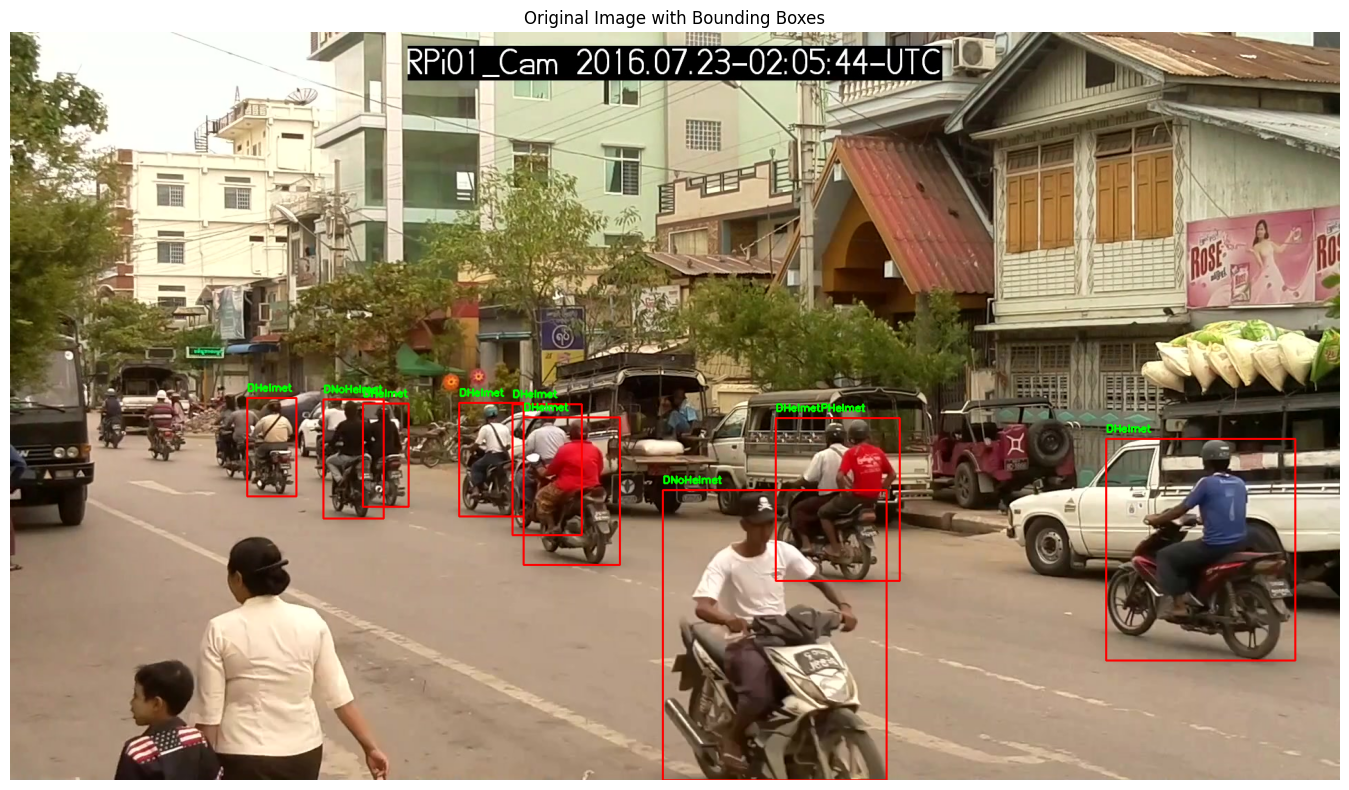

In [278]:
image_re = cv2.imread(image_path)
image_cv = cv2.cvtColor(image_re, cv2.COLOR_BGR2RGB)

original_height, original_width = image_cv.shape[:2]

scale_x = original_width / 512
scale_y = original_height / 512

image_with_boxes = image_cv.copy()

img = image_path.split("\\")[-1].split(".")[0] 
bboxes = data_test.loc[data_test['image_name'] == img, 'bbox'].values[0]
labels = data_test.loc[data_test['image_name'] == img, 'new_labels'].values[0]

for box, label in zip(bboxes, labels):
    xmin, ymin, xmax, ymax = box
    # Chỉnh lại tọa độ về kích thước gốc
    xmin_orig = int(xmin)
    ymin_orig = int(ymin)
    xmax_orig = int(xmax)
    ymax_orig = int(ymax)
    label_text = label
    cv2.rectangle(image_with_boxes,
                  (xmin_orig, ymin_orig),
                  (xmax_orig, ymax_orig),
                  (255, 0, 0), 2)  
    cv2.putText(image_with_boxes, label_text,
                (xmin_orig, ymin_orig - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5, (0, 255, 0), 2) 

plt.figure(figsize = (16, 8))

plt.imshow(image_with_boxes)
plt.axis("off")
plt.title("Original Image with Bounding Boxes")

plt.tight_layout()
plt.show()

### Dự đoán ảnh

In [501]:
img_list = [r'images\Bago_highway_31_90.jpg',r'images\Bago_rural_43_69.jpg',r'images\Yangon_II_33_77.jpg',r'images\Yangon_II_33_38.jpg',r'images\Mandalay_2_115_19.jpg',r'images\Mandalay_1_155_27.jpg',r'images\Mandalay_1_152_72.jpg',r'images\Yangon_II_29_39.jpg',r'images\Naypyitaw_2_34_55.jpg',r'images\Bago_highway_29_45.jpg',r'images\Mandalay_1_155_01.jpg',r'images\Mandalay_2_113_29.jpg',r'images\Mandalay_2_173_57.jpg',]

In [465]:
image_path = r"images\Mandalay_2_115_19.jpg"
image = Image.open(image_path).convert("RGB")
image_tensor = transform(image).unsqueeze(0) 

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
image_tensor = image_tensor.to(device)

with torch.no_grad(): 
    predictions = model(image_tensor)

predictions 

[{'boxes': tensor([[183.8734, 241.3572, 222.7475, 315.1866],
          [108.6532, 295.4041, 223.3153, 511.0927],
          [332.9396, 293.3858, 506.2608, 511.8806],
          [347.7817, 277.5710, 508.1271, 498.7607],
          [144.5547, 257.2535, 215.7945, 420.8495],
          [149.2477, 260.1826, 216.6788, 418.7756],
          [353.7751, 275.5681, 504.5592, 501.5663],
          [119.7637, 284.6511, 213.9386, 451.7271],
          [123.3590, 257.8258, 181.9460, 379.3981],
          [186.0676, 236.9683, 210.9898, 294.6283],
          [142.4660, 251.5490, 218.5623, 423.4332],
          [223.8154, 239.8170, 249.0292, 298.8049],
          [109.3508, 294.9471, 226.5875, 511.0070]]),
  'labels': tensor([2, 3, 2, 3, 3, 2, 4, 2, 2, 2, 4, 2, 4]),
  'scores': tensor([0.9951, 0.9804, 0.9580, 0.8569, 0.7736, 0.7162, 0.2226, 0.1441, 0.1119,
          0.0696, 0.0578, 0.0541, 0.0530])}]

In [498]:
predicted_boxes = predictions[0]['boxes'].cpu().numpy()
predicted_labels = predictions[0]['labels'].cpu().numpy()
predicted_scores = predictions[0]['scores'].cpu().numpy()

threshold = 0.2
filtered_indices = predicted_scores > threshold

filtered_boxes = predicted_boxes[filtered_indices]
filtered_labels = predicted_labels[filtered_indices]
filtered_scores = predicted_scores[filtered_indices]

for i in range(len(filtered_boxes)):
    print(f"Box: {filtered_boxes[i]}, Label: {filtered_labels[i]}, Score: {filtered_scores[i]}")

Box: [183.87335 241.35718 222.74745 315.18665], Label: 2, Score: 0.9950705766677856
Box: [108.65319 295.40414 223.3153  511.09265], Label: 3, Score: 0.9803738594055176
Box: [332.93964 293.3858  506.2608  511.88058], Label: 2, Score: 0.9579980969429016
Box: [347.78168 277.57098 508.12714 498.76065], Label: 3, Score: 0.8568562269210815
Box: [144.55473 257.25348 215.79453 420.84955], Label: 3, Score: 0.7736127972602844
Box: [149.24768 260.1826  216.67877 418.7756 ], Label: 2, Score: 0.7162211537361145
Box: [353.7751  275.56805 504.5592  501.5663 ], Label: 4, Score: 0.22255955636501312


In [499]:
predicted_boxes = predictions[0]['boxes'].cpu()
predicted_labels = predictions[0]['labels'].cpu()
predicted_scores = predictions[0]['scores'].cpu()

filtered_boxes = predicted_boxes[filtered_indices]
filtered_labels = predicted_labels[filtered_indices]
filtered_scores = predicted_scores[filtered_indices]

# Áp dụng NMS
iou_threshold = 0.4  # Ngưỡng IoU để loại bỏ các box dư thừa
nms_indices = nms(filtered_boxes, filtered_scores, iou_threshold)

# Lấy các box, label, score sau khi áp dụng NMS
filtered_boxes = filtered_boxes[nms_indices]
filtered_labels = filtered_labels[nms_indices]
filtered_scores = filtered_scores[nms_indices]

# In kết quả sau khi áp dụng NMS
for i in range(len(filtered_boxes)):
    print(f"Box: {filtered_boxes[i].numpy()}, Label: {filtered_labels[i].item()}, Score: {filtered_scores[i].item()}")
    
filtered_labels = filtered_labels.numpy()

Box: [183.87335 241.35718 222.74745 315.18665], Label: 2, Score: 0.9950705766677856
Box: [108.65319 295.40414 223.3153  511.09265], Label: 3, Score: 0.9803738594055176
Box: [332.93964 293.3858  506.2608  511.88058], Label: 2, Score: 0.9579980969429016
Box: [144.55473 257.25348 215.79453 420.84955], Label: 3, Score: 0.7736127972602844


### Test ảnh trong bộ Test - Validation

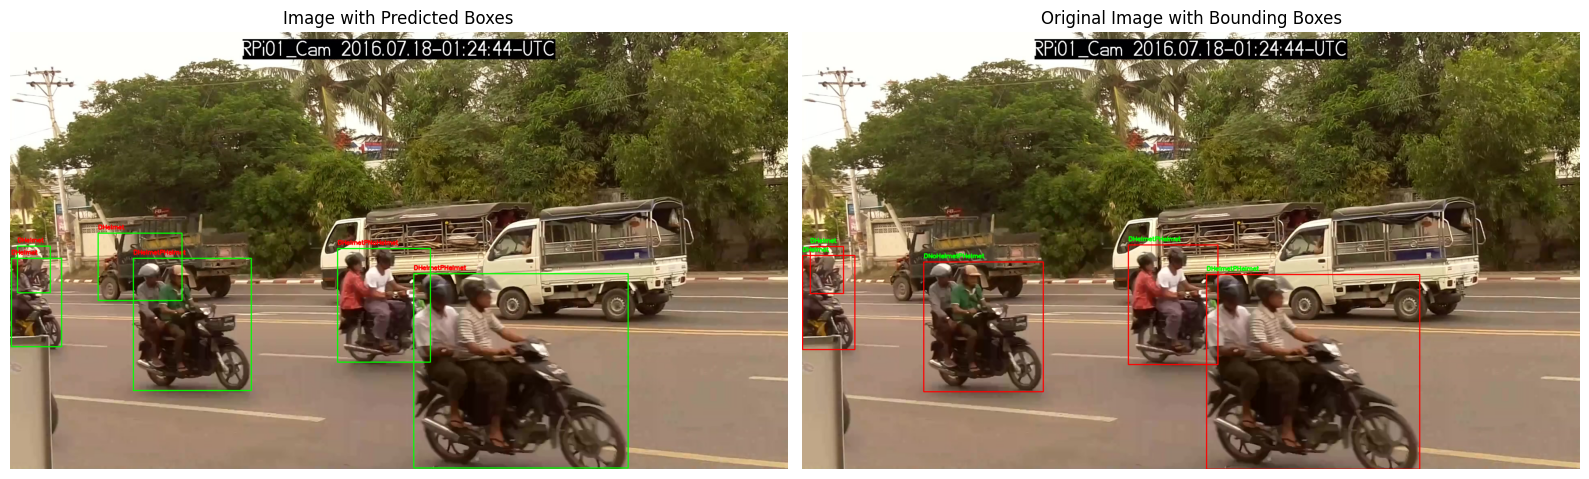

In [425]:
image_re = cv2.imread(image_path)
image_cv = cv2.cvtColor(image_re, cv2.COLOR_BGR2RGB)

original_height, original_width = image_cv.shape[:2]
resized_image = cv2.resize(image_cv, (512, 512))

scale_x = original_width / 512
scale_y = original_height / 512

for box, label in zip(filtered_boxes, filtered_labels):
    xmin, ymin, xmax, ymax = box
    label_text = label_mapping_2[int(label)]
    cv2.rectangle(resized_image, 
                  (int(xmin), int(ymin)), 
                  (int(xmax), int(ymax)), 
                  (0, 255, 0), 2)
    # Thêm nhãn vào bounding box
    cv2.putText(resized_image, label_text, 
                (int(xmin), int(ymin) - 10),  
                cv2.FONT_HERSHEY_SIMPLEX, 
                0.5, (255, 0, 0), 2)  

resized_back_image = cv2.resize(resized_image, (original_width, original_height))

adjusted_image = image_cv.copy()  
for box, label in zip(filtered_boxes, filtered_labels):
    xmin, ymin, xmax, ymax = box

    xmin_orig = int(xmin * scale_x)
    ymin_orig = int(ymin * scale_y)
    xmax_orig = int(xmax * scale_x)
    ymax_orig = int(ymax * scale_y)
    label_text = label_mapping_2[int(label)]
    cv2.rectangle(adjusted_image, 
                  (xmin_orig, ymin_orig), 
                  (xmax_orig, ymax_orig), 
                  (0, 255, 0), 2)

    cv2.putText(adjusted_image, label_text, 
                (xmin_orig, ymin_orig - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 
                0.5, (255, 0, 0), 2) 

image_with_boxes = image_cv.copy()

img = image_path.split("\\")[-1].split(".")[0] 
bboxes = data_test.loc[data_test['image_name'] == img, 'bbox'].values[0]
labels = data_test.loc[data_test['image_name'] == img, 'new_labels'].values[0]

for box, label in zip(bboxes, labels):
    xmin, ymin, xmax, ymax = box
    # Chỉnh lại tọa độ về kích thước gốc
    xmin_orig = int(xmin)
    ymin_orig = int(ymin)
    xmax_orig = int(xmax)
    ymax_orig = int(ymax)
    label_text = label
    cv2.rectangle(image_with_boxes,
                  (xmin_orig, ymin_orig),
                  (xmax_orig, ymax_orig),
                  (255, 0, 0), 2)  
    cv2.putText(image_with_boxes, label_text,
                (xmin_orig, ymin_orig - 10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5, (0, 255, 0), 2) 

plt.figure(figsize = (16, 8))

plt.subplot(1, 2, 1)
plt.imshow(adjusted_image)
plt.axis("off")
plt.title("Image with Predicted Boxes")

plt.subplot(1, 2, 2)
plt.imshow(image_with_boxes)
plt.axis("off")
plt.title("Original Image with Bounding Boxes")

plt.tight_layout()
plt.show()

### Test trên ảnh thực tế

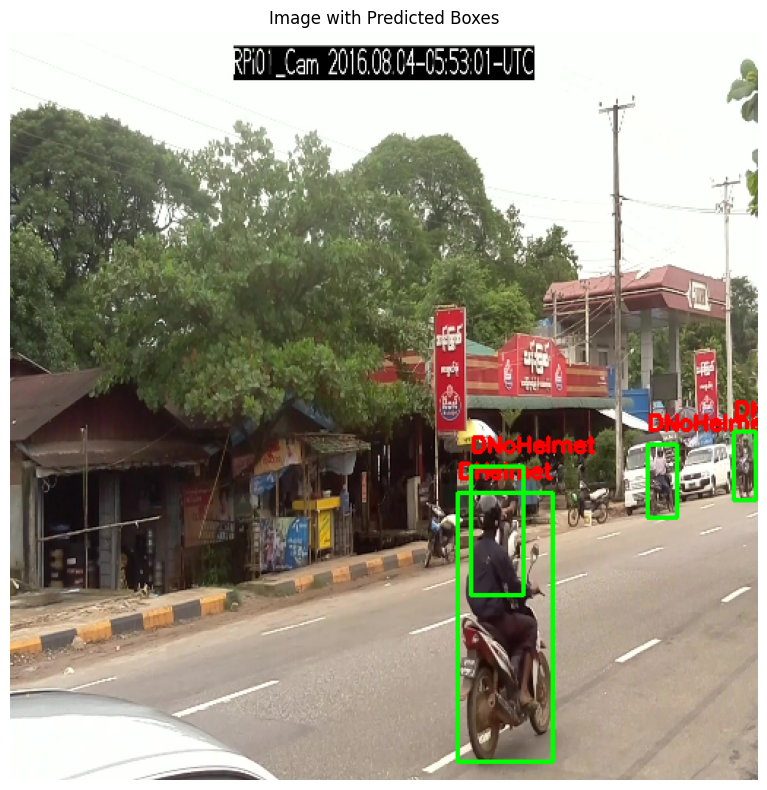

In [336]:
img_PIL = Image.open(image_path)
image_cv = img_PIL.convert("RGB")
image_cv = np.array(image_cv)

original_height, original_width = image_cv.shape[:2]
resized_image = cv2.resize(image_cv, (512, 512))

scale_x = original_width / 512
scale_y = original_height / 512

for box, label in zip(filtered_boxes, filtered_labels):
    xmin, ymin, xmax, ymax = box
    label_text = label_mapping_2[int(label)]

    cv2.rectangle(resized_image, 
                  (int(xmin), int(ymin)), 
                  (int(xmax), int(ymax)), 
                  (0, 255, 0), 2)
    # Thêm nhãn vào bounding box
    cv2.putText(resized_image, label_text, 
                (int(xmin), int(ymin) - 10),  
                cv2.FONT_HERSHEY_SIMPLEX, 
                0.5, (255, 0, 0), 2)  

# resized_back_image = cv2.resize(resized_image, (original_width, original_height))

# adjusted_image = image_cv.copy()  
# for box, label in zip(filtered_boxes, filtered_labels):
#     xmin, ymin, xmax, ymax = box

#     xmin_orig = int(xmin * scale_x)
#     ymin_orig = int(ymin * scale_y)
#     xmax_orig = int(xmax * scale_x)
#     ymax_orig = int(ymax * scale_y)
#     label_text = label_mapping_2[int(label)]
#     cv2.rectangle(adjusted_image, 
#                   (xmin_orig, ymin_orig), 
#                   (xmax_orig, ymax_orig), 
#                   (0, 255, 0), 2)

#     cv2.putText(adjusted_image, label_text, 
#                 (xmin_orig, ymin_orig - 10),
#                 cv2.FONT_HERSHEY_SIMPLEX, 
#                 0.5, (255, 0, 0), 2) 
    
plt.figure(figsize = (16, 8))

plt.imshow(resized_image)
plt.axis("off")
plt.title("Image with Predicted Boxes")

plt.tight_layout()
plt.show()


### Thực tế 

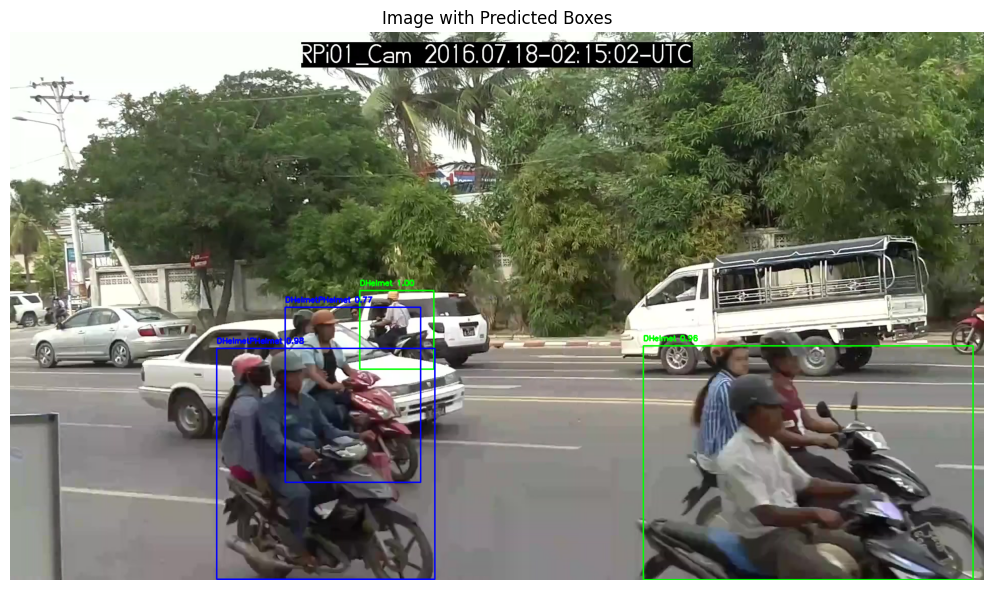

In [504]:
img_PIL = Image.open(image_path)
image_cv = img_PIL.convert("RGB")
image_cv = np.array(image_cv)

original_height, original_width = image_cv.shape[:2]
resized_image = cv2.resize(image_cv, (512, 512))

scale_x = original_width / 512
scale_y = original_height / 512

adjusted_image = image_cv.copy()
colors = [
    (255, 0, 0),    # Màu đỏ
    (0, 255, 0),    # Màu xanh lá
    (0, 0, 255),    # Màu xanh dương
    (255, 255, 0),  # Màu vàng
    (255, 0, 255),  # Màu hồng
    (0, 255, 255),  # Màu lục lam
]
for box, label, score in zip(filtered_boxes, filtered_labels, filtered_scores):
    xmin, ymin, xmax, ymax = box
    
    xmin_orig = int(xmin * scale_x)
    ymin_orig = int(ymin * scale_y)
    xmax_orig = int(xmax * scale_x)
    ymax_orig = int(ymax * scale_y)
    label_text = label_mapping_2[label]
    combine_text = f'{label_text} {score:0.2f}'
    color = colors[(int(label) - 1) % len(colors)]
    cv2.rectangle(adjusted_image, 
                  (xmin_orig, ymin_orig), 
                  (xmax_orig, ymax_orig), 
                  color, 2)
    
    cv2.putText(adjusted_image, combine_text, 
                (xmin_orig, ymin_orig - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 
                0.5, color, 2)  
   

plt.figure(figsize = (12,6))

plt.imshow(adjusted_image)
plt.axis("off")
plt.title("Image with Predicted Boxes")

plt.tight_layout()
plt.show()